## Контрольная работа

#### Задание:

**Используя данные из обучающего датасета (train.csv), построить модель для предсказания цен на недвижимость (квартиры).
С помощью полученной модели, предсказать цены для квартир из тестового датасета (test.csv).**

**Целевая переменная:**
Price

**Метрика качества:**
R2 - коэффициент детерминации (sklearn.metrics.r2_score)

**Требования к решению:**
1. R2 > 0.6
2. Тетрадка Jupyter Notebook с кодом Вашего решения, названная по образцу {ФИО}_solution.ipynb, пример SShirkin_solution.ipynb
3. Файл CSV с прогнозами целевой переменной для тестового датасета, названный по образцу {ФИО}_predictions.csv, пример SShirkin_predictions.csv 
Файл должен содержать два поля: Id, Price и в файле должна быть 5001 строка (шапка + 5000 предсказаний).

**Рекомендации для файла с кодом (ipynb):**
1. Файл должен содержать заголовки и комментарии (markdown)
2. Повторяющиеся операции лучше оформлять в виде функций
3. Не делать вывод большого количества строк таблиц (5-10 достаточно)
4. По возможности добавлять графики, описывающие данные (около 3-5)
5. Добавлять только лучшую модель, то есть не включать в код все варианты решения проекта
6. Скрипт проекта должен отрабатывать от начала и до конца (от загрузки данных до выгрузки предсказаний)
7. Весь проект должен быть в одном скрипте (файл ipynb).

**Описание датасета:**
* **Id** - идентификационный номер квартиры
* **DistrictId** - идентификационный номер района
* **Rooms** - количество комнат
* **Square** - площадь
* **LifeSquare** - жилая площадь
* **KitchenSquare** - площадь кухни
* **Floor** - этаж
* **HouseFloor** - количество этажей в доме
* **HouseYear** - год постройки дома
* **Ecology_1, Ecology_2, Ecology_3** - экологические показатели местности
* **Social_1, Social_2, Social_3** - социальные показатели местности
* **Healthcare_1, Helthcare_2** - показатели местности, связанные с охраной здоровья
* **Shops_1, Shops_2** - показатели, связанные с наличием магазинов, торговых центров
* **Price** - цена квартиры

### EDA

In [1]:
# подключим часть библиотек с которыми будем работать

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.image as img
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({'font.size': 14})  # размер шрифта на графиках

Загрузим данные и посмотрим с чем мы имеем дело


In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             10000 non-null  int64  
 1   DistrictId     10000 non-null  int64  
 2   Rooms          10000 non-null  float64
 3   Square         10000 non-null  float64
 4   LifeSquare     7887 non-null   float64
 5   KitchenSquare  10000 non-null  float64
 6   Floor          10000 non-null  int64  
 7   HouseFloor     10000 non-null  float64
 8   HouseYear      10000 non-null  int64  
 9   Ecology_1      10000 non-null  float64
 10  Ecology_2      10000 non-null  object 
 11  Ecology_3      10000 non-null  object 
 12  Social_1       10000 non-null  int64  
 13  Social_2       10000 non-null  int64  
 14  Social_3       10000 non-null  int64  
 15  Healthcare_1   5202 non-null   float64
 16  Helthcare_2    10000 non-null  int64  
 17  Shops_1        10000 non-null  int64  
 18  Shops_2

Уменьшим размерность данных

In [4]:
def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

df = reduce_mem_usage(df)

Memory usage of dataframe is 1.53 MB
Memory usage after optimization is: 0.49 MB
Decreased by 68.1%


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             10000 non-null  int16   
 1   DistrictId     10000 non-null  int16   
 2   Rooms          10000 non-null  float32 
 3   Square         10000 non-null  float32 
 4   LifeSquare     7887 non-null   float32 
 5   KitchenSquare  10000 non-null  float32 
 6   Floor          10000 non-null  int8    
 7   HouseFloor     10000 non-null  float32 
 8   HouseYear      10000 non-null  int32   
 9   Ecology_1      10000 non-null  float32 
 10  Ecology_2      10000 non-null  category
 11  Ecology_3      10000 non-null  category
 12  Social_1       10000 non-null  int8    
 13  Social_2       10000 non-null  int16   
 14  Social_3       10000 non-null  int16   
 15  Healthcare_1   5202 non-null   float32 
 16  Helthcare_2    10000 non-null  int8    
 17  Shops_1        10000 non-null  i

In [6]:
df.head(10)

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
0,14038,35,2.0,47.981560,29.442751,6.0,7,9.0,1969,0.089040,B,B,33,7976,5,NaN,0,11,B,184966.937500
1,15053,41,3.0,65.683640,40.049541,8.0,7,9.0,1978,0.000070,B,B,46,10309,1,240.0,1,16,B,300009.437500
2,4765,53,2.0,44.947952,29.197611,0.0,8,12.0,1968,0.049637,B,B,34,7759,0,229.0,1,3,B,220925.906250
3,5809,58,2.0,53.352982,52.731510,9.0,8,17.0,1977,0.437885,B,B,23,5735,3,1084.0,0,5,B,175616.234375
4,10783,99,1.0,39.649193,23.776169,7.0,11,12.0,1976,0.012339,B,B,35,5776,1,2078.0,2,4,B,150226.531250
5,12915,59,3.0,80.384476,46.683720,12.0,5,17.0,2011,0.309479,B,B,35,7715,4,990.0,0,6,B,215898.453125
6,14549,154,2.0,62.254112,37.160378,7.0,3,5.0,1960,0.460556,B,B,20,4386,14,NaN,1,5,B,296021.218750
7,11993,74,2.0,80.312927,NaN,0.0,14,0.0,1977,0.075779,B,B,6,1437,3,NaN,0,2,B,221244.156250
8,5172,1,2.0,64.511436,NaN,1.0,9,17.0,1977,0.007122,B,B,1,264,0,NaN,0,1,B,229102.796875
9,8649,23,1.0,46.461411,18.915552,8.0,13,17.0,2014,0.075779,B,B,6,1437,3,NaN,0,2,B,95380.218750


In [7]:
df.describe().style.format('{:.2f}')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,10000.00,10000.00,10000.00,10000.00,7887.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,5202.00,10000.00,10000.00,10000.00
mean,8383.41,50.40,1.89,56.32,37.20,6.27,8.53,12.61,3990.17,0.12,24.69,5352.16,8.04,1142.90,1.32,4.23,214138.86
std,4859.02,43.59,0.84,21.06,86.24,28.56,5.24,6.78,200500.26,0.12,17.53,4006.80,23.83,1021.52,1.49,4.81,92872.30
min,0.00,0.00,0.00,1.14,0.37,0.00,1.00,0.00,1910.00,0.00,0.00,168.00,0.00,0.00,0.00,0.00,59174.78
25%,4169.50,20.00,1.00,41.77,22.77,1.00,4.00,9.00,1974.00,0.02,6.00,1564.00,0.00,350.00,0.00,1.00,153872.63
50%,8394.50,36.00,2.00,52.51,32.78,6.00,7.00,13.00,1977.00,0.08,25.00,5285.00,2.00,900.00,1.00,3.00,192269.65
75%,12592.50,75.00,2.00,65.90,45.13,9.00,12.00,17.00,2001.00,0.20,36.00,7227.00,5.00,1548.00,2.00,6.00,249135.46
max,16798.00,209.00,19.00,641.07,7480.59,2014.00,42.00,117.00,20052011.00,0.52,74.00,19083.00,141.00,4849.00,6.00,23.00,633233.44


По информации из данных мы видим что у нас есть три категориальных признака **Ecology_2**, **Ecology_3**, **Shops_2** и два призака с пропусками **LifeSquare**, **Healthcare_1**

Так же явно бросаются в глаза выбросы в признаках Square	**LifeSquare, KitchenSquare, HouseFloor, HouseYear** у которых сильно завышены максимальные значения 

### Загрузим тестовые данные

In [8]:
df_test = pd.read_csv('test.csv')

In [9]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             5000 non-null   int64  
 1   DistrictId     5000 non-null   int64  
 2   Rooms          5000 non-null   float64
 3   Square         5000 non-null   float64
 4   LifeSquare     3959 non-null   float64
 5   KitchenSquare  5000 non-null   float64
 6   Floor          5000 non-null   int64  
 7   HouseFloor     5000 non-null   float64
 8   HouseYear      5000 non-null   int64  
 9   Ecology_1      5000 non-null   float64
 10  Ecology_2      5000 non-null   object 
 11  Ecology_3      5000 non-null   object 
 12  Social_1       5000 non-null   int64  
 13  Social_2       5000 non-null   int64  
 14  Social_3       5000 non-null   int64  
 15  Healthcare_1   2623 non-null   float64
 16  Helthcare_2    5000 non-null   int64  
 17  Shops_1        5000 non-null   int64  
 18  Shops_2 

In [10]:
df_test.head(10)

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
0,725,58,2.0,49.882643,33.432782,6.0,6,14.0,1972,0.310199,B,B,11,2748,1,NaN,0,0,B
1,15856,74,2.0,69.263183,NaN,1.0,6,1.0,1977,0.075779,B,B,6,1437,3,NaN,0,2,B
2,5480,190,1.0,13.597819,15.948246,12.0,2,5.0,1909,0.000000,B,B,30,7538,87,4702.0,5,5,B
3,15664,47,2.0,73.046609,51.940842,9.0,22,22.0,2007,0.101872,B,B,23,4583,3,NaN,3,3,B
4,14275,27,1.0,47.527111,43.387569,1.0,17,17.0,2017,0.072158,B,B,2,629,1,NaN,0,0,A
5,7633,53,1.0,40.675627,NaN,1.0,21,21.0,1977,0.049637,B,B,34,7759,0,229.0,1,3,B
6,13329,23,2.0,68.099538,64.843025,1.0,2,17.0,1977,0.075779,B,B,6,1437,3,NaN,0,2,B
7,5502,32,2.0,48.193897,32.857644,6.0,5,14.0,1972,0.135650,B,B,46,7960,6,350.0,3,11,B
8,4220,96,3.0,72.277106,45.968758,9.0,17,17.0,1997,0.041116,B,B,53,14892,4,NaN,1,4,B
9,11538,6,3.0,80.219400,47.660260,9.0,13,17.0,2014,0.243205,B,B,5,1564,0,540.0,0,0,B


In [11]:
df_test.describe()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1
count,5000.000000,5000.000000,5000.000000,5000.000000,3959.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,2623.000000,5000.00000,5000.000000
mean,8412.595400,51.279200,1.910000,56.449500,36.158810,5.976800,8.632000,12.601000,1984.392600,0.119874,24.933800,5406.900000,8.262600,1146.657263,1.31940,4.242800
std,4832.674037,44.179466,0.838594,19.092787,17.825287,9.950018,5.483228,6.789213,18.573149,0.120070,17.532202,4026.614773,23.863762,1044.744231,1.47994,4.777365
min,1.000000,0.000000,0.000000,1.378543,0.333490,0.000000,1.000000,0.000000,1908.000000,0.000000,0.000000,168.000000,0.000000,0.000000,0.00000,0.000000
25%,4221.750000,21.000000,1.000000,41.906231,23.092026,1.000000,4.000000,9.000000,1973.000000,0.019509,6.000000,1564.000000,0.000000,325.000000,0.00000,1.000000
50%,8320.500000,37.000000,2.000000,52.921340,32.925087,6.000000,7.000000,12.000000,1977.000000,0.072158,25.000000,5285.000000,2.000000,900.000000,1.00000,3.000000
75%,12598.250000,77.000000,2.000000,66.285129,45.174091,9.000000,12.000000,17.000000,2000.000000,0.195781,36.000000,7287.000000,5.000000,1548.000000,2.00000,6.000000
max,16795.000000,212.000000,17.000000,223.453689,303.071094,620.000000,78.000000,99.000000,2020.000000,0.521867,74.000000,19083.000000,141.000000,4849.000000,6.00000,23.000000


In [12]:
df.describe().style.format('{:.2f}')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,10000.00,10000.00,10000.00,10000.00,7887.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,5202.00,10000.00,10000.00,10000.00
mean,8383.41,50.40,1.89,56.32,37.20,6.27,8.53,12.61,3990.17,0.12,24.69,5352.16,8.04,1142.90,1.32,4.23,214138.86
std,4859.02,43.59,0.84,21.06,86.24,28.56,5.24,6.78,200500.26,0.12,17.53,4006.80,23.83,1021.52,1.49,4.81,92872.30
min,0.00,0.00,0.00,1.14,0.37,0.00,1.00,0.00,1910.00,0.00,0.00,168.00,0.00,0.00,0.00,0.00,59174.78
25%,4169.50,20.00,1.00,41.77,22.77,1.00,4.00,9.00,1974.00,0.02,6.00,1564.00,0.00,350.00,0.00,1.00,153872.63
50%,8394.50,36.00,2.00,52.51,32.78,6.00,7.00,13.00,1977.00,0.08,25.00,5285.00,2.00,900.00,1.00,3.00,192269.65
75%,12592.50,75.00,2.00,65.90,45.13,9.00,12.00,17.00,2001.00,0.20,36.00,7227.00,5.00,1548.00,2.00,6.00,249135.46
max,16798.00,209.00,19.00,641.07,7480.59,2014.00,42.00,117.00,20052011.00,0.52,74.00,19083.00,141.00,4849.00,6.00,23.00,633233.44


При визуальном осмотре нашего тестового дата сета, на котором мы в итого и должны сделать предсказания можно увидеть, что тестовые данные схожи с обучаемыми! Не очень ясно логика по цифрам, например пложадь кухни больше в цифрах чем площадь основная и жилая площадь!  Есть значения в признаках тестовом дата сете ,которые отсутствуют в обучающем! И главное там есть так же пропуски, которые нужно будет чем то заполнять - главное сконцентрируемся на этом! Заполнение нулями или медианой, средним оставим! Попробуем собрать модель для нахождения зависимостей в данных и заполним их предсказанными значениями!

Явные выбросы в обучающей выборке попробуем удалить, возможно их будет не так много! 

## План работы

**Общая идея заключается в следующем : так как представленный для теста дата сет имеет схожие данные и шаблоны с обучающим и логика заполнения данными тестового и обучающего дата сетов не совсем ясна, но имеются явные кореляции между признаками попробуем их найти и на основании этого построить основную модель! Что бы попытаться улучшить качество модели попробуем более точно заполнить пропуски в данных , так как их очень много в признаках в которых они отсутствуют! Для этого постоим дополнительную модели! Данная модель должны заполнить пропуки и уже на основании полных данных попробуем построить основную модель! Таким образом план работы будет следующим:**


1. Выбросм из данных train явные максимальные значения по выбросам! Остальные выбросы оставим как есть.
2. Построим матрицу корреляции признаков
3. Выделим два дата сета - однин с признаками коррелирующими с LifeSquare, второй - с коррелирующими с Healthcare_1.
4. Обучим модели для заполнения пропусков
5. После заполним пропуски и обучим основную модель на обновленном train
6. После закинем наш тест в доп модели для заполнения пропусков
7. После закинем полученный test в основную модель и спрогназируем наш таргет.

#### 1. Обработка выбросов 

**LifeSquare**

In [13]:
df[df['LifeSquare']>700]

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
4328,16550,27,3.0,81.69442,7480.592285,1.0,9,17.0,2016,0.017647,B,B,2,469,0,NaN,0,0,B,217357.5


In [14]:
df = df.drop(df[df['LifeSquare']>700].index)

In [15]:
df.describe()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,9999.000000,9999.000000,9999.000000,9999.000000,7886.000000,9999.000000,9999.000000,9999.000000,9.999000e+03,9999.000000,9999.000000,9999.000000,9999.000000,5202.000000,9999.000000,9999.000000,9999.000000
mean,8382.590959,50.403140,1.890389,56.313236,36.255768,6.273828,8.526653,12.608961,3.990364e+03,0.118868,24.689269,5352.645765,8.040004,1142.904419,1.319632,4.231723,214138.531250
std,4858.575511,43.589143,0.839520,21.058254,20.275122,28.562485,5.241408,6.776282,2.005103e+05,0.119027,17.532023,4006.702533,23.832931,1021.518982,1.493617,4.806395,92876.953125
min,0.000000,0.000000,0.000000,1.136859,0.370619,0.000000,1.000000,0.000000,1.910000e+03,0.000000,0.000000,168.000000,0.000000,0.000000,0.000000,0.000000,59174.777344
25%,4169.000000,20.000000,1.000000,41.774311,22.769573,1.000000,4.000000,9.000000,1.974000e+03,0.017647,6.000000,1564.000000,0.000000,350.000000,0.000000,1.000000,153860.585938
50%,8394.000000,36.000000,2.000000,52.512768,32.776848,6.000000,7.000000,13.000000,1.977000e+03,0.075424,25.000000,5285.000000,2.000000,900.000000,1.000000,3.000000,192261.968750
75%,12591.500000,75.000000,2.000000,65.896008,45.126160,9.000000,12.000000,17.000000,2.001000e+03,0.195781,36.000000,7227.000000,5.000000,1548.000000,2.000000,6.000000,249148.484375
max,16798.000000,209.000000,19.000000,641.065186,638.163208,2014.000000,42.000000,117.000000,2.005201e+07,0.521867,74.000000,19083.000000,141.000000,4849.000000,6.000000,23.000000,633233.437500


**KitchenSquare**

In [16]:
df[df['KitchenSquare']>124]

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
1064,14656,62,1.0,47.100719,46.447960,2014.0,4,1.0,2014,0.072158,B,B,2,629,1,NaN,0,0,A,108337.484375
8584,14679,81,1.0,32.276665,19.278395,1970.0,6,1.0,1977,0.006076,B,B,30,5285,0,645.0,6,6,B,105539.554688


In [17]:
df = df.drop(df[df['KitchenSquare']>124].index)

In [18]:
df.describe().style.format('{:.2f}')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,9997.00,9997.00,9997.00,9997.00,7884.00,9997.00,9997.00,9997.00,9997.00,9997.00,9997.00,9997.00,9997.00,5201.00,9997.00,9997.00,9997.00
mean,8381.33,50.40,1.89,56.32,36.26,5.88,8.53,12.61,3990.76,0.12,24.69,5353.13,8.04,1143.00,1.32,4.23,214159.98
std,4858.25,43.59,0.84,21.06,20.28,5.17,5.24,6.77,200530.34,0.12,17.53,4006.82,23.84,1021.59,1.49,4.81,92873.74
min,0.00,0.00,0.00,1.14,0.37,0.00,1.00,0.00,1910.00,0.00,0.00,168.00,0.00,0.00,0.00,0.00,59174.78
25%,4168.00,20.00,1.00,41.78,22.77,1.00,4.00,9.00,1974.00,0.02,6.00,1564.00,0.00,350.00,0.00,1.00,153893.98
50%,8393.00,36.00,2.00,52.51,32.78,6.00,7.00,13.00,1977.00,0.08,25.00,5285.00,2.00,900.00,1.00,3.00,192277.33
75%,12590.00,75.00,2.00,65.90,45.12,9.00,12.00,17.00,2001.00,0.20,36.00,7227.00,5.00,1548.00,2.00,6.00,249174.53
max,16798.00,209.00,19.00,641.07,638.16,123.00,42.00,117.00,20052011.00,0.52,74.00,19083.00,141.00,4849.00,6.00,23.00,633233.44


**HouseYear**

In [19]:
df[df['HouseYear']>2025]

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
1497,10814,109,1.0,37.265072,20.239714,9.0,9,12.0,20052011,0.136330,B,B,30,6141,10,262.0,3,6,B,254084.531250
4189,11607,147,2.0,44.791836,28.360394,5.0,4,9.0,4968,0.319809,B,B,25,4756,16,2857.0,5,8,B,243028.609375


In [20]:
df = df.drop(df[df['HouseYear']>2025].index)

In [21]:
df.describe()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,9995.000000,9995.000000,9995.000000,9995.000000,7882.000000,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000,5199.000000,9995.000000,9995.000000,9995.000000
mean,8380.767484,50.383392,1.890645,56.319622,36.259666,5.876338,8.527764,12.611706,1984.860130,0.118862,24.690445,5353.105953,8.040520,1142.839966,1.318759,4.231416,214153.109375
std,4858.566045,43.581982,0.839490,21.059729,20.278021,5.174997,5.242003,6.775322,18.409139,0.119028,17.533901,4007.213422,23.837319,1021.444214,1.492575,4.806957,92881.671875
min,0.000000,0.000000,0.000000,1.136859,0.370619,0.000000,1.000000,0.000000,1910.000000,0.000000,0.000000,168.000000,0.000000,0.000000,0.000000,0.000000,59174.777344
25%,4167.500000,20.000000,1.000000,41.777519,22.772655,1.000000,4.000000,9.000000,1974.000000,0.017647,6.000000,1564.000000,0.000000,350.000000,0.000000,1.000000,153889.328125
50%,8392.000000,35.000000,2.000000,52.524544,32.782780,6.000000,7.000000,13.000000,1977.000000,0.075424,25.000000,5285.000000,2.000000,900.000000,1.000000,3.000000,192261.968750
75%,12590.500000,75.000000,2.000000,65.901825,45.126160,9.000000,12.000000,17.000000,2001.000000,0.195781,36.000000,7227.000000,5.000000,1548.000000,2.000000,6.000000,249148.484375
max,16798.000000,209.000000,19.000000,641.065186,638.163208,123.000000,42.000000,117.000000,2020.000000,0.521867,74.000000,19083.000000,141.000000,4849.000000,6.000000,23.000000,633233.437500


**Переведем бинарные признки в числовые**

In [27]:
df['Ecology_2'] = df['Ecology_2'].map({'A': 1, 'B': 0})
df['Ecology_3'] = df['Ecology_3'].map({'A': 1, 'B': 0})
df['Shops_2'] = df['Shops_2'].map({'A': 1, 'B': 0})

In [28]:
df.head()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
0,14038,35,2.0,47.981560,29.442751,6.0,7,9.0,1969,0.089040,NaN,NaN,33,7976,5,NaN,0,11,NaN,184966.937500
1,15053,41,3.0,65.683640,40.049541,8.0,7,9.0,1978,0.000070,NaN,NaN,46,10309,1,240.0,1,16,NaN,300009.437500
2,4765,53,2.0,44.947952,29.197611,0.0,8,12.0,1968,0.049637,NaN,NaN,34,7759,0,229.0,1,3,NaN,220925.906250
3,5809,58,2.0,53.352982,52.731510,9.0,8,17.0,1977,0.437885,NaN,NaN,23,5735,3,1084.0,0,5,NaN,175616.234375
4,10783,99,1.0,39.649193,23.776169,7.0,11,12.0,1976,0.012339,NaN,NaN,35,5776,1,2078.0,2,4,NaN,150226.531250


#### 2. Построим матрицу кореляции признаков

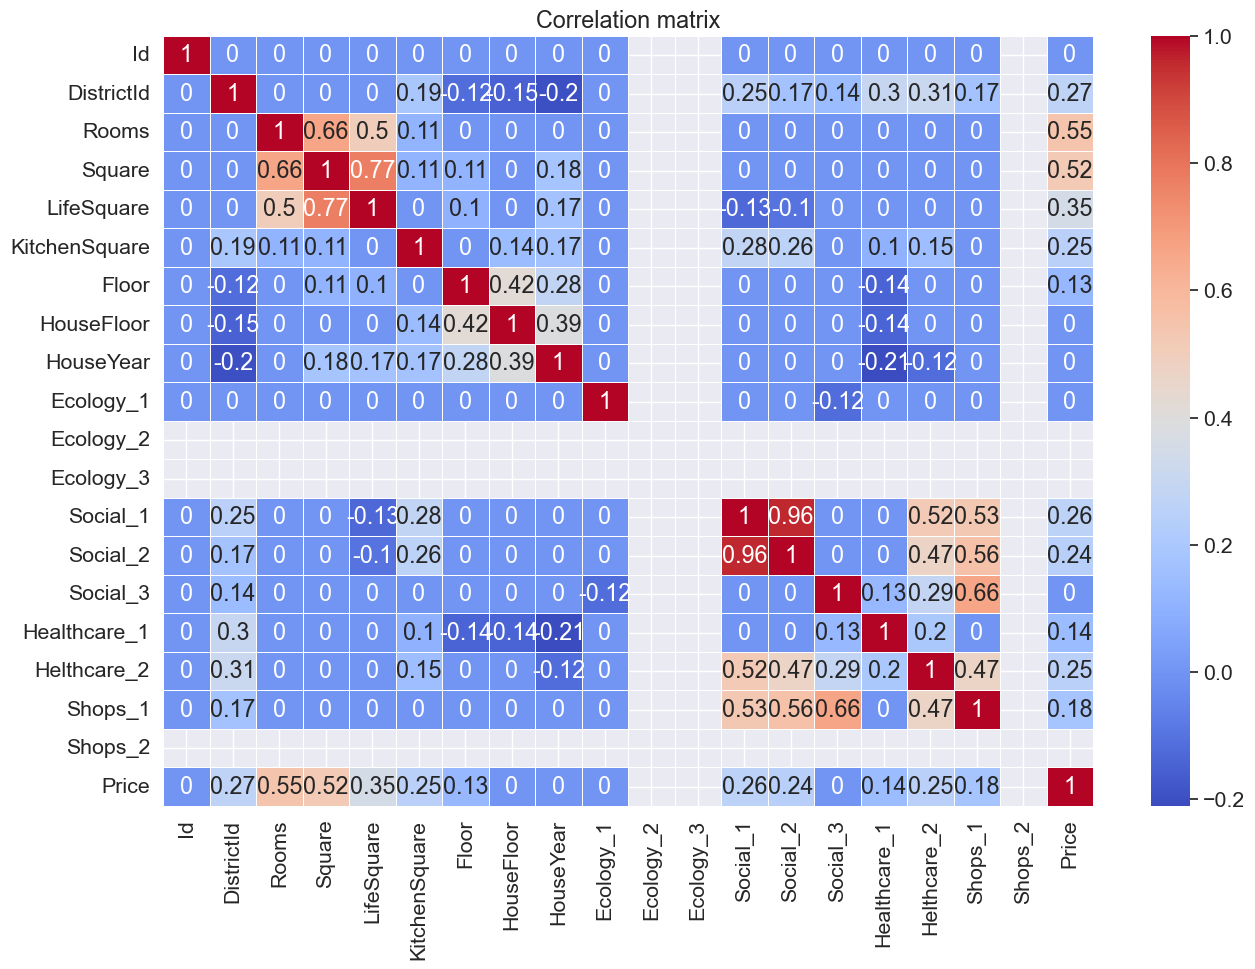

In [32]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize = (15,10))

sns.set(font_scale=1.4)

corr_matrix = numeric_df.corr()
corr_matrix = np.round(corr_matrix, 2)
corr_matrix[np.abs(corr_matrix) < 0.1] = 0

sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap='coolwarm')

plt.title('Correlation matrix')
plt.show()

### 3. Выделение датасетов

Выделим признаки коррелирующие с признаком LifeSquare и Healthcare_1 кроме 'Price'

In [43]:
df_LifeSquare = df[['DistrictId','Rooms','Square','Floor', 'HouseFloor','HouseYear','Social_1','Social_2','LifeSquare']]

In [44]:
df_Healthcare = df[['DistrictId', 'KitchenSquare', 'Floor', 'HouseFloor', 'HouseYear', 'Social_1', 'Social_2', 'Social_3', 'Helthcare_2', 'Healthcare_1']]

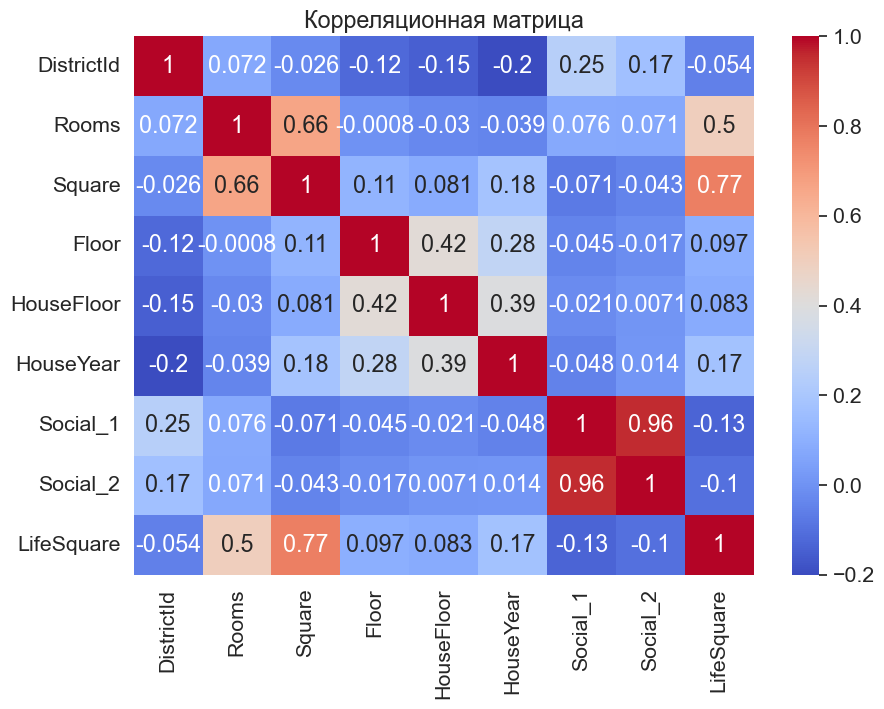

In [45]:
corr = df_LifeSquare.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

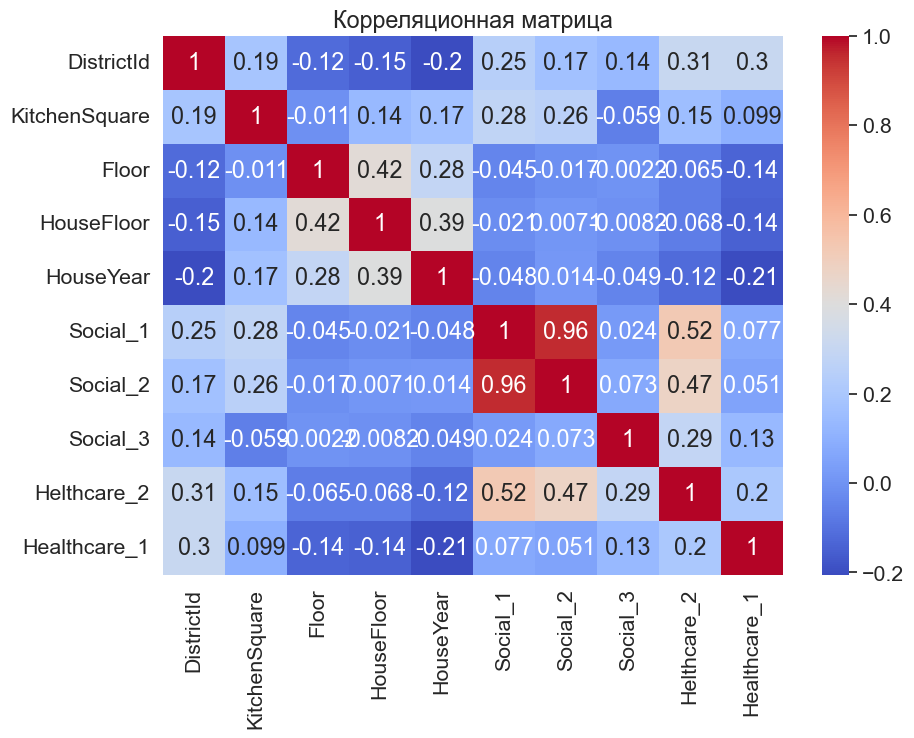

In [46]:
corr = df_Healthcare.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

### 4.Обучение первод модели для пропусков

In [59]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_absolute_error


In [60]:
# Целевая переменная
target_1 = "LifeSquare"

In [61]:
# Признаки
features_1 = ['DistrictId','Rooms','Square','Floor', 'HouseFloor','HouseYear','Social_1','Social_2']

In [62]:
# Категориальные признаки
cat_features_1 = ["DistrictId"]

In [63]:
# Разделяем данные
train_df_1 = df_LifeSquare[df_LifeSquare[target_1].notna()].copy()
test_df_1  = df_LifeSquare[df_LifeSquare[target_1].isna()].copy()

X_train_1 = train_df_1[features_1]
y_train_1 = train_df_1[target_1]
X_test_1  = test_df_1[features_1]

In [64]:
# ==== Подготовка CatBoost Pool ====
train_pool_1 = Pool(X_train_1, label=y_train_1, cat_features=cat_features_1)
test_pool_1  = Pool(X_test_1,  cat_features=cat_features_1)

In [65]:
# ====== Модель CatBoost ======
model_1 = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)

In [66]:
model_1.fit(train_pool_1)

0:	learn: 20.0051972	total: 37.4ms	remaining: 56.1s
200:	learn: 11.0381890	total: 7.35s	remaining: 47.5s
400:	learn: 9.9178034	total: 14.7s	remaining: 40.3s
600:	learn: 8.7891542	total: 22s	remaining: 33s
800:	learn: 8.0687668	total: 29.5s	remaining: 25.7s
1000:	learn: 7.5005476	total: 37.1s	remaining: 18.5s
1200:	learn: 7.0441059	total: 44.6s	remaining: 11.1s
1400:	learn: 6.6620644	total: 52.2s	remaining: 3.69s
1499:	learn: 6.4849389	total: 55.9s	remaining: 0us


In [67]:
# ====== Предсказание пропущенных значений ======
preds_1 = model_1.predict(test_pool_1)

df_LifeSquare["LifeSquare_filled"] = df_LifeSquare["LifeSquare"]
df_LifeSquare.loc[df_LifeSquare[target_1].isna(), "LifeSquare_filled"] = preds_1

print("Готово! Пропуски в LifeSquare заполнены в колонке LifeSquare_filled.")


Готово! Пропуски в LifeSquare заполнены в колонке LifeSquare_filled.


In [68]:
# ====== Оценка качества ======
train_preds_1 = model_1.predict(train_pool_1)

print("R2:", r2_score(y_train_1, train_preds_1))
print("MAE:", mean_absolute_error(y_train_1, train_preds_1))

R2: 0.8801318643996685
MAE: 3.9576645499523426


In [69]:
# ====== Важность признаков ======
print("\nFeature Importance:")
imp_1 = model_1.get_feature_importance(train_pool_1)
for f, w in sorted(zip(features_1, imp_1), key=lambda x: -x[1]):
    print(f"{f}: {w:.2f}")


Feature Importance:
Square: 33.66
HouseYear: 17.69
Rooms: 10.37
HouseFloor: 9.09
DistrictId: 8.40
Social_2: 7.50
Social_1: 6.68
Floor: 6.62


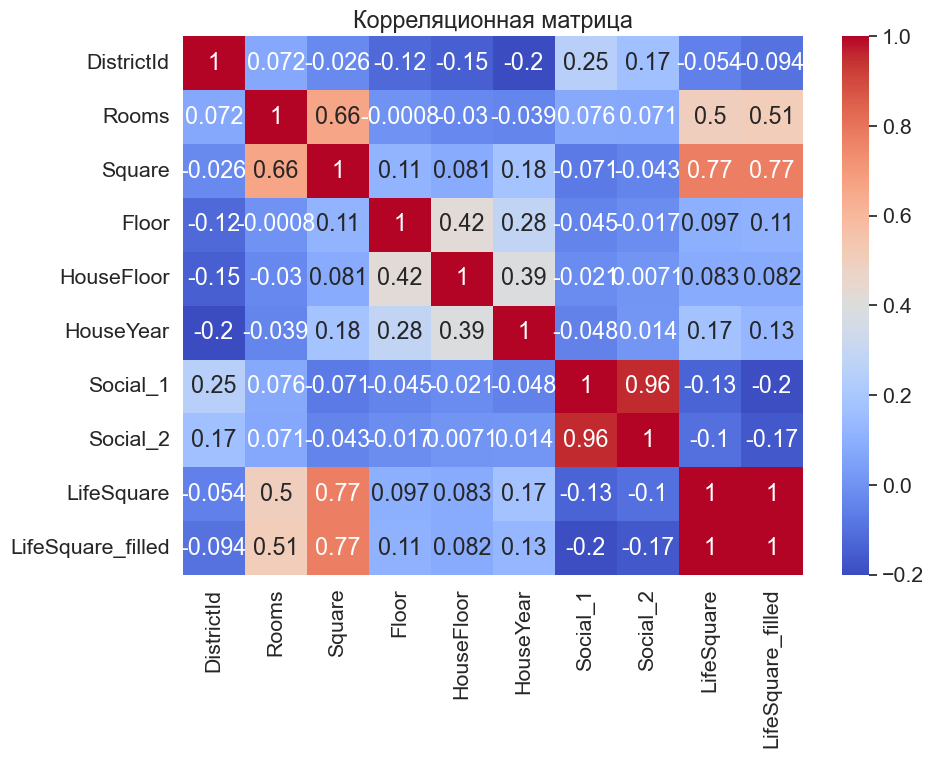

In [70]:
corr = df_LifeSquare.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

In [71]:
df_LifeSquare

,DistrictId,Rooms,Square,Floor,HouseFloor,HouseYear,Social_1,Social_2,LifeSquare,LifeSquare_filled
0,35,2.0,47.981560,7,9.0,1969,33,7976,29.442751,29.442751
1,41,3.0,65.683640,7,9.0,1978,46,10309,40.049541,40.049541
2,53,2.0,44.947952,8,12.0,1968,34,7759,29.197611,29.197611
3,58,2.0,53.352982,8,17.0,1977,23,5735,52.731510,52.731510
4,99,1.0,39.649193,11,12.0,1976,35,5776,23.776169,23.776169
...,...,...,...,...,...,...,...,...,...,...
9995,32,2.0,50.401787,6,5.0,1968,46,7960,30.476204,30.476204
9996,18,1.0,41.521545,13,13.0,2000,30,5562,20.539215,20.539215
9997,27,1.0,47.939007,12,16.0,2015,2,629,NaN,33.165499
9998,75,2.0,43.602562,1,5.0,1961,30,5048,33.840149,33.840149
